<a href="https://colab.research.google.com/github/M2004GV/M2004GV/blob/output/bracol_cnn_vs_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Setup

In [ ]:
import collections
import collections.abc
collections.Mapping = collections.abc.Mapping
collections.MutableMapping = collections.abc.MutableMapping
collections.Iterable = collections.abc.Iterable
collections.Callable = collections.abc.Callable

In [ ]:
import os, glob, time, zipfile, numpy as np, pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from scipy.stats import binom
import matplotlib.pyplot as plt

# ---- reprodutibilidade (a GPU ainda tem não determinismo residual) ----
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED); tf.random.set_seed(SEED)

# ---- caminhos FIXOS no Drive (a pasta "Meu Drive" monta como "MyDrive") ----
DRIVE_BASE = "/content/drive/MyDrive/coffee-datasets/coffee-datasets/leaf"
IMAGES_DIR = f"{DRIVE_BASE}/images"
CSV_PATH   = f"{DRIVE_BASE}/dataset.csv"


IMG_SIZE = 224
BATCH    = 32
EPOCHS_SCRATCH     = 20    # rede do zero
EPOCHS_TL_FROZEN   = 12    # transfer: extração de características
EPOCHS_TL_FINETUNE = 6     # transfer: ajuste fino
FINE_TUNE_AT = 100         # congela as primeiras N camadas da base no ajuste fino


STRESS_TO_CLASS = {0:"saudavel", 1:"bicho_mineiro", 2:"ferrugem",
                   3:"mancha_phoma", 4:"cercosporiose"}

print("TensorFlow", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU') or "NENHUMA — ative a GPU no runtime")


TensorFlow 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ---- montar o Drive e conferir os caminhos ----
from google.colab import drive
drive.mount('/content/drive')

assert os.path.isdir(DRIVE_BASE), f"Não achei a pasta: {DRIVE_BASE}"
assert os.path.isdir(IMAGES_DIR), f"Não achei a pasta de imagens: {IMAGES_DIR}"
if not os.path.exists(CSV_PATH):                       # caso o CSV tenha outro nome
    cands = glob.glob(os.path.join(DRIVE_BASE, "*.csv"))
    assert cands, f"Nenhum .csv em {DRIVE_BASE}"
    CSV_PATH = cands[0]
print("CSV:", CSV_PATH)
print("arquivos em images/:", len(glob.glob(os.path.join(IMAGES_DIR, '**', '*'), recursive=True)))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV: /content/drive/MyDrive/coffee-datasets/coffee-datasets/leaf/dataset.csv
arquivos em images/: 689


## 1. Dados — BRACOL (folhas inteiras)

O rótulo está na coluna `predominant_stress` do CSV. As 62 folhas com múltiplos estresses sem
predominância (`predominant_stress == 5`) são descartadas, restando 5 classes. Cada imagem é
localizada na pasta `images/` pelo seu `id`.

In [ ]:
df = pd.read_csv(CSV_PATH)
n0 = len(df)
df = df[df["predominant_stress"].isin(STRESS_TO_CLASS)].copy()
df["classe"] = df["predominant_stress"].map(STRESS_TO_CLASS)
print(f"linhas no CSV: {n0} -> {len(df)} usadas (removidos {n0-len(df)} ambíguos)")

# indexa os arquivos de imagem por id (tolera zero-padding nos nomes)
file_index = {}
for p in glob.glob(os.path.join(IMAGES_DIR, "**", "*"), recursive=True):
    if p.lower().endswith((".jpg", ".jpeg", ".png")):
        stem = os.path.splitext(os.path.basename(p))[0]
        file_index[stem] = p
        if stem.isdigit():
            file_index[str(int(stem))] = p

CLASSES   = sorted(STRESS_TO_CLASS.values())   # ordem fixa das classes
N_CLASSES = len(CLASSES)
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
_DISPLAY = {"saudavel":"saudável", "bicho_mineiro":"bicho-mineiro", "ferrugem":"ferrugem",
            "mancha_phoma":"mancha-de-phoma", "cercosporiose":"cercosporiose"}
LABELS_FIG = [_DISPLAY[c] for c in CLASSES]

paths, labels, missing = [], [], 0
for _, r in df.iterrows():
    p = file_index.get(str(int(r["id"])))
    if p is None:
        missing += 1; continue
    paths.append(p); labels.append(class_to_idx[r["classe"]])
paths, labels = np.array(paths), np.array(labels)

print(f"imagens encontradas: {len(paths)} | não encontradas: {missing}")
for i, c in enumerate(CLASSES):
    print(f"  {c:16s}: {(labels==i).sum()}")


linhas no CSV: 1747 -> 1685 usadas (removidos 62 ambíguos)
imagens encontradas: 653 | não encontradas: 1032
  bicho_mineiro   : 167
  cercosporiose   : 68
  ferrugem        : 360
  mancha_phoma    : 5
  saudavel        : 53


In [ ]:
# ---- split estratificado 70/15/15 (preserva a proporção das classes) ----
p_tr, p_tmp, y_tr, y_tmp = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
p_va, p_te, y_va, y_te = train_test_split(
    p_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print(f"treino {len(p_tr)} | validação {len(p_va)} | teste {len(p_te)}")
print("teste por classe:", np.bincount(y_te, minlength=N_CLASSES))

# ---- pesos de classe: compensam o desbalanceamento (ex.: cercospora é minoria) ----
counts = np.bincount(y_tr, minlength=N_CLASSES); total = counts.sum()
class_weight = {i: float(total/(N_CLASSES*c)) if c > 0 else 0.0
                for i, c in enumerate(counts)}
print("pesos:", {CLASSES[i]: round(w, 2) for i, w in class_weight.items()})


treino 457 | validação 98 | teste 98
teste por classe: [25 10 54  1  8]
pesos: {'bicho_mineiro': 0.78, 'cercosporiose': 1.9, 'ferrugem': 0.36, 'mancha_phoma': 30.47, 'saudavel': 2.47}


In [ ]:
# ---- pipeline tf.data: lê, decodifica e redimensiona ----
def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return img, label

def make_ds(p, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((p, y))
    if training:
        ds = ds.shuffle(len(p), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(p_tr, y_tr, training=True)
val_ds   = make_ds(p_va, y_va)
test_ds  = make_ds(p_te, y_te)

# ---- aumento de dados (só no treino, embutido no modelo) ----
augment = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augment")


## 2. Modelo A — CNN construída do zero (linha de base)

Quatro blocos convolucionais (Conv → BatchNorm → ReLU → MaxPooling), agrupamento médio global,
dropout e uma camada densa antes da saída *softmax*.

In [ ]:
def build_scratch():
    inp = layers.Input((IMG_SIZE, IMG_SIZE, 3))
    x = augment(inp)
    x = layers.Rescaling(1./255)(x)
    for f in (32, 64, 128, 128):
        x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization(momentum=0.9)(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(N_CLASSES, activation="softmax")(x)
    m = models.Model(inp, out, name="cnn_do_zero")
    m.compile(optimizer=optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

scratch = build_scratch()
scratch.summary()


Model: "cnn_do_zero"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 259,045 (1011.89 KB)

 Trainable params: 258,341 (1009.14 KB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6),
]

t0 = time.time()
hist_scratch = scratch.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_SCRATCH,
    class_weight=class_weight, callbacks=cbs, verbose=1)
time_scratch = time.time() - t0
print(f"\nTempo de treino (CNN do zero): {time_scratch:.1f}s")


Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 30s 223ms/step - accuracy: 0.3457 - loss: 1.6973 - val_accuracy: 0.0102 - val_loss: 2.5217 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 440ms/step - accuracy: 0.4683 - loss: 1.4421 - val_accuracy: 0.0102 - val_loss: 1.7435 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 307ms/step - accuracy: 0.4333 - loss: 1.3646 - val_accuracy: 0.2551 - val_loss: 1.4666 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 269ms/step - accuracy: 0.4004 - loss: 1.4090 - val_accuracy: 0.2551 - val_loss: 1.3921 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 411ms/step - accuracy: 0.4048 - loss: 1.3328 - val_accuracy: 0.1531 - val_loss: 2.8407 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 269ms/step - accuracy: 0.5208 - loss: 1.1904 - val_accuracy: 0.5102 - val_loss: 1.1903 - learning_rate: 0.0010
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 455ms/step - accuracy: 0.5317 - loss: 1.2226 -

## 3. Modelo B — Transferência de Aprendizado (MobileNetV2)

**Fase 1:** base pré-treinada na ImageNet congelada, só o cabeçalho novo aprende.
**Fase 2:** o topo da base é descongelado e ajustado com taxa de aprendizado bem menor.
A base é chamada com `training=False` para manter a BatchNorm em modo de inferência (recomendado no ajuste fino).

In [ ]:
def build_transfer():
    inp = layers.Input((IMG_SIZE, IMG_SIZE, 3))
    x = augment(inp)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)  # escala para [-1, 1]
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
    base.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(N_CLASSES, activation="softmax")(x)
    m = models.Model(inp, out, name="mobilenetv2_transfer")
    m.compile(optimizer=optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m, base

transfer, base = build_transfer()
print("Parâmetros totais:", transfer.count_params())


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parâmetros totais: 2264389


In [ ]:
# ---- Fase 1: extração de características (base congelada) ----
t0 = time.time()
hist_tl1 = transfer.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_TL_FROZEN,
    class_weight=class_weight, callbacks=cbs, verbose=1)


Epoch 1/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 398ms/step - accuracy: 0.2429 - loss: 2.4441 - val_accuracy: 0.3878 - val_loss: 1.3177 - learning_rate: 0.0010
Epoch 2/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 302ms/step - accuracy: 0.3698 - loss: 1.8459 - val_accuracy: 0.3878 - val_loss: 1.4512 - learning_rate: 0.0010
Epoch 3/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 390ms/step - accuracy: 0.3807 - loss: 1.4254 - val_accuracy: 0.6224 - val_loss: 1.0719 - learning_rate: 0.0010
Epoch 4/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 306ms/step - accuracy: 0.5077 - loss: 1.1276 - val_accuracy: 0.6429 - val_loss: 1.0333 - learning_rate: 3.0000e-04
Epoch 5/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 398ms/step - accuracy: 0.5427 - loss: 1.1512 - val_accuracy: 0.6327 - val_loss: 1.0147 - learning_rate: 3.0000e-04
Epoch 6/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 280ms/step - accuracy: 0.4595 - loss: 1.2500 - val_accuracy: 0.6531 - val_loss: 0.9982 - learning_rate: 3.0000e-04
Epoch 7/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 288ms/step - accuracy: 0.5339 - lo

In [ ]:
# ---- Fase 2: ajuste fino (descongela o topo, recompila com LR menor) ----
# guarda os pesos bons da fase 1 (rede de segurança contra colapso no ajuste fino)
w_fase1 = transfer.get_weights()
best_val_fase1 = max(hist_tl1.history["val_accuracy"])

# descongela o topo da base, MAS mantém TODA a BatchNorm congelada.
# (descongelar a BatchNorm é o que faz a MobileNetV2 colapsar no ajuste fino.)
base.trainable = True
for i, layer in enumerate(base.layers):
    if isinstance(layer, layers.BatchNormalization) or i < FINE_TUNE_AT:
        layer.trainable = False

transfer.compile(optimizer=optimizers.Adam(1e-5, clipnorm=1.0),  # LR baixa + recorte de gradiente
                 loss="sparse_categorical_crossentropy", metrics=["accuracy"])

hist_tl2 = transfer.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_TL_FINETUNE,
    class_weight=class_weight, callbacks=cbs, verbose=1)
time_transfer = time.time() - t0
boundary = len(hist_tl1.history["loss"])   # época onde começa o ajuste fino (p/ a figura)

# rede de segurança: se o ajuste fino piorou a validação, volta aos pesos da fase 1
if max(hist_tl2.history["val_accuracy"]) < best_val_fase1:
    transfer.set_weights(w_fase1)
    print("Ajuste fino piorou a validação; pesos da fase 1 restaurados.")
print(f"\nTempo de treino (Transfer Learning): {time_transfer:.1f}s")


Epoch 1/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 368ms/step - accuracy: 0.6193 - loss: 1.2351 - val_accuracy: 0.5918 - val_loss: 0.9664 - learning_rate: 1.0000e-05
Epoch 2/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 411ms/step - accuracy: 0.6630 - loss: 0.9641 - val_accuracy: 0.7143 - val_loss: 0.7110 - learning_rate: 1.0000e-05
Epoch 3/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.6958 - loss: 0.7356 - val_accuracy: 0.7245 - val_loss: 0.6744 - learning_rate: 1.0000e-05
Epoch 4/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 273ms/step - accuracy: 0.7571 - loss: 0.6427 - val_accuracy: 0.7041 - val_loss: 0.7174 - learning_rate: 1.0000e-05
Epoch 5/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 404ms/step - accuracy: 0.7352 - loss: 0.7977 - val_accuracy: 0.7551 - val_loss: 0.6201 - learning_rate: 1.0000e-05
Epoch 6/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 274ms/step - accuracy: 0.7287 - loss: 0.8607 - val_accuracy: 0.7245 - val_loss: 0.6308 - learning_rate: 1.0000e-05

Tempo de treino (Transfer Learning): 111.6s


## 4. Avaliação no conjunto de teste

In [ ]:
def predict_labels(model, ds):
    probs = model.predict(ds, verbose=0)
    return np.argmax(probs, axis=1), probs

pred_scratch, _  = predict_labels(scratch, test_ds)
pred_transfer, _ = predict_labels(transfer, test_ds)

def report(name, y_pred):
    acc = accuracy_score(y_te, y_pred); f1 = f1_score(y_te, y_pred, average="macro")
    print(f"\n===== {name} =====")
    print(f"Acurácia: {acc:.4f} | F1 macro: {f1:.4f}")
    print(classification_report(y_te, y_pred, target_names=LABELS_FIG, zero_division=0))
    return acc, f1

acc_s, f1_s = report("CNN do zero", pred_scratch)
acc_t, f1_t = report("Transfer Learning (MobileNetV2)", pred_transfer)

# ---- Tabela 1 do relatório ----
tabela = pd.DataFrame({
    "Modelo": ["CNN do zero", "Transfer Learning (MobileNetV2)"],
    "Acurácia": [f"{acc_s*100:.2f}%", f"{acc_t*100:.2f}%"],
    "F1 macro": [f"{f1_s:.4f}", f"{f1_t:.4f}"],
    "Parâmetros": [scratch.count_params(), transfer.count_params()],
    "Tempo (s)": [f"{time_scratch:.1f}", f"{time_transfer:.1f}"],
})
tabela.to_csv("tabela_comparativa.csv", index=False)
tabela



===== CNN do zero =====
Acurácia: 0.6020 | F1 macro: 0.2516
                 precision    recall  f1-score   support

  bicho-mineiro       0.40      0.08      0.13        25
  cercosporiose       0.00      0.00      0.00        10
       ferrugem       0.70      1.00      0.82        54
mancha-de-phoma       0.00      0.00      0.00         1
       saudável       0.25      0.38      0.30         8

       accuracy                           0.60        98
      macro avg       0.27      0.29      0.25        98
   weighted avg       0.51      0.60      0.51        98


===== Transfer Learning (MobileNetV2) =====
Acurácia: 0.7551 | F1 macro: 0.5556
                 precision    recall  f1-score   support

  bicho-mineiro       0.71      0.60      0.65        25
  cercosporiose       0.40      0.60      0.48        10
       ferrugem       0.88      0.85      0.87        54
mancha-de-phoma       0.00      0.00      0.00         1
       saudável       0.70      0.88      0.78         8

,Modelo,Acurácia,F1 macro,Parâmetros,Tempo (s)
0,CNN do zero,60.20%,0.2516,259045,103.4
1,Transfer Learning (MobileNetV2),75.51%,0.5556,2264389,111.6


In [ ]:
# ---- Teste de McNemar (compara os dois classificadores nos MESMOS exemplos) ----
def mcnemar_exact(y_true, p1, p2):
    c1, c2 = (p1 == y_true), (p2 == y_true)
    b = int(np.sum(c1 & ~c2)); c = int(np.sum(~c1 & c2)); n = b + c
    if n == 0: return b, c, 1.0
    return b, c, min(1.0, 2.0 * binom.cdf(min(b, c), n, 0.5))

b, c, pval = mcnemar_exact(y_te, pred_scratch, pred_transfer)
print(f"do_zero acerta & transfer erra: {b} | transfer acerta & do_zero erra: {c}")
print(f"McNemar (binomial exato): p = {pval:.4f}")
print("Diferença estatisticamente significativa (alpha=0.05)." if pval < 0.05
      else "Sem evidência de diferença significativa a alpha=0.05 (verifique com mais sementes).")


do_zero acerta & transfer erra: 8 | transfer acerta & do_zero erra: 23
McNemar (binomial exato): p = 0.0107
Diferença estatisticamente significativa (alpha=0.05).


## 5. Figuras para o relatório

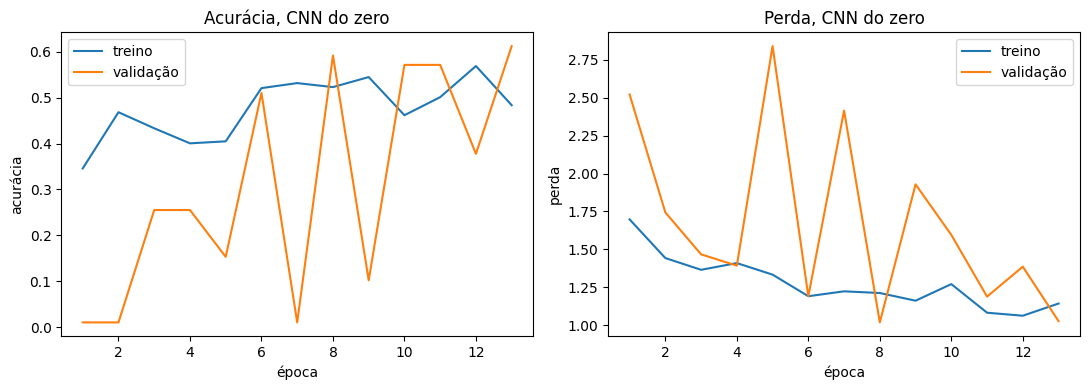

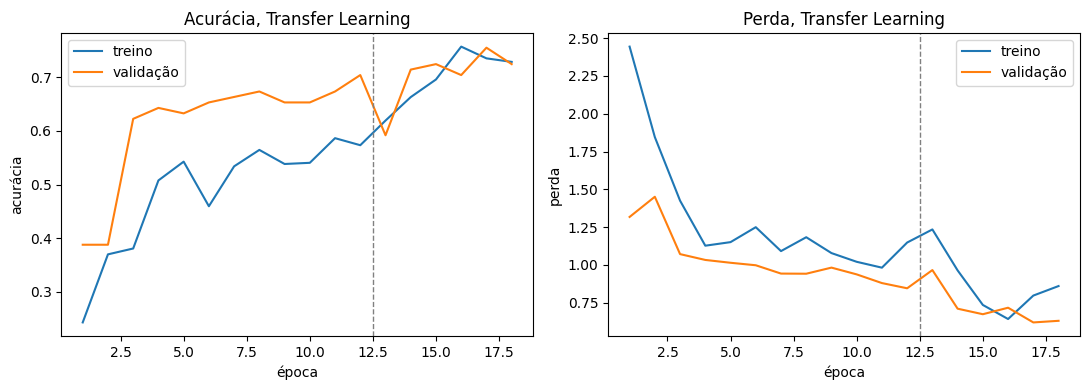

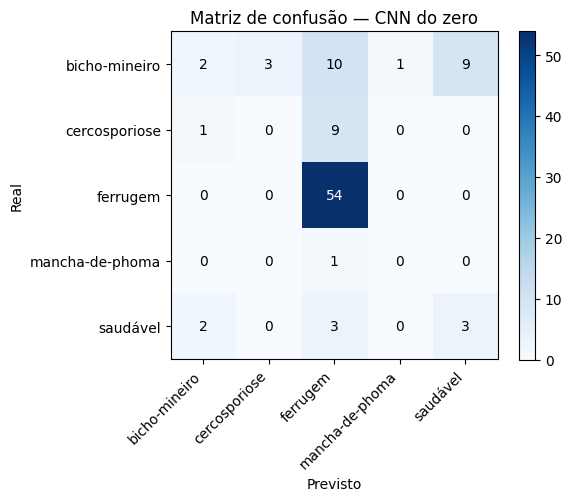

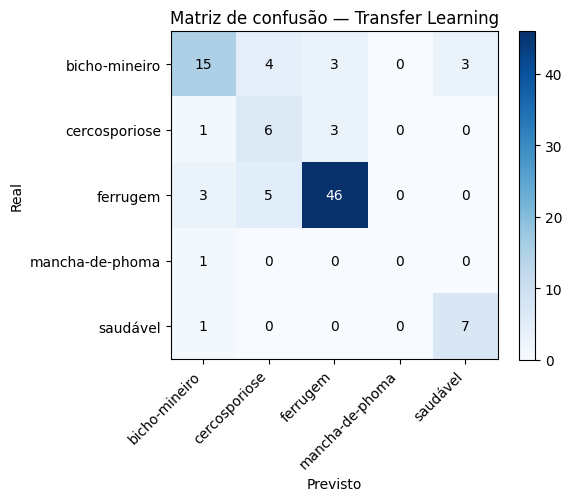

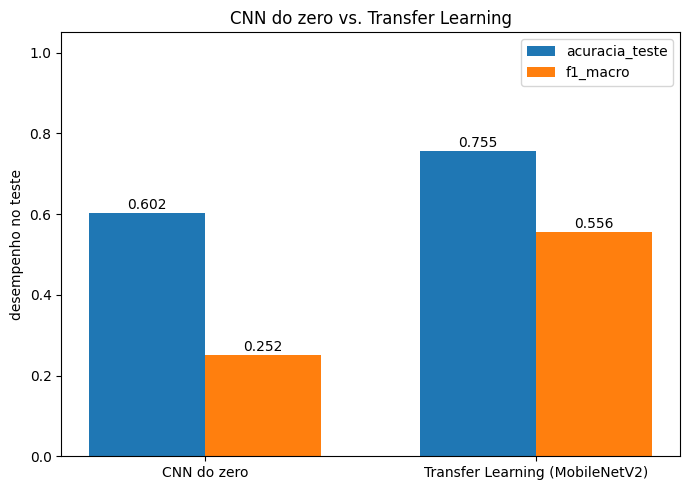

In [ ]:
def plot_learning(history_dicts, title, fname, boundary=None):
    acc = sum([h["accuracy"] for h in history_dicts], [])
    val_acc = sum([h["val_accuracy"] for h in history_dicts], [])
    loss = sum([h["loss"] for h in history_dicts], [])
    val_loss = sum([h["val_loss"] for h in history_dicts], [])
    ep = range(1, len(acc)+1)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(ep, acc, label="treino"); ax[0].plot(ep, val_acc, label="validação")
    ax[0].set_title(f"Acurácia, {title}"); ax[0].set_xlabel("época"); ax[0].set_ylabel("acurácia"); ax[0].legend()
    ax[1].plot(ep, loss, label="treino"); ax[1].plot(ep, val_loss, label="validação")
    ax[1].set_title(f"Perda, {title}"); ax[1].set_xlabel("época"); ax[1].set_ylabel("perda"); ax[1].legend()
    if boundary:
        for a in ax: a.axvline(boundary + 0.5, ls="--", color="gray", lw=1)
    fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()

def plot_cm(cm, title, fname):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(LABELS_FIG, rotation=45, ha="right"); ax.set_yticklabels(LABELS_FIG)
    ax.set_xlabel("Previsto"); ax.set_ylabel("Real"); ax.set_title(title)
    thr = cm.max()/2 if cm.max() else 0.5
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > thr else "black")
    fig.colorbar(im); fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()

def plot_compare(fname):
    fig, ax = plt.subplots(figsize=(7, 5)); x = np.arange(2); w = 0.35
    ax.bar(x - w/2, [acc_s, acc_t], w, label="acuracia_teste")
    ax.bar(x + w/2, [f1_s, f1_t], w, label="f1_macro")
    for i, v in enumerate([acc_s, acc_t]): ax.text(i - w/2, v+0.01, f"{v:.3f}", ha="center")
    for i, v in enumerate([f1_s, f1_t]):   ax.text(i + w/2, v+0.01, f"{v:.3f}", ha="center")
    ax.set_xticks(x); ax.set_xticklabels(["CNN do zero", "Transfer Learning (MobileNetV2)"])
    ax.set_ylim(0, 1.05); ax.set_ylabel("desempenho no teste")
    ax.set_title("CNN do zero vs. Transfer Learning"); ax.legend()
    fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()

plot_learning([hist_scratch.history], "CNN do zero", "fig_curva_scratch.png")
plot_learning([hist_tl1.history, hist_tl2.history], "Transfer Learning",
              "fig_curva_transfer.png", boundary=boundary)
plot_cm(confusion_matrix(y_te, pred_scratch),  "Matriz de confusão — CNN do zero", "fig_cm_scratch.png")
plot_cm(confusion_matrix(y_te, pred_transfer), "Matriz de confusão — Transfer Learning", "fig_cm_transfer.png")
plot_compare("fig_compare.png")


## 6. Demonstração de inferência

Verde = acerto, vermelho = erro.

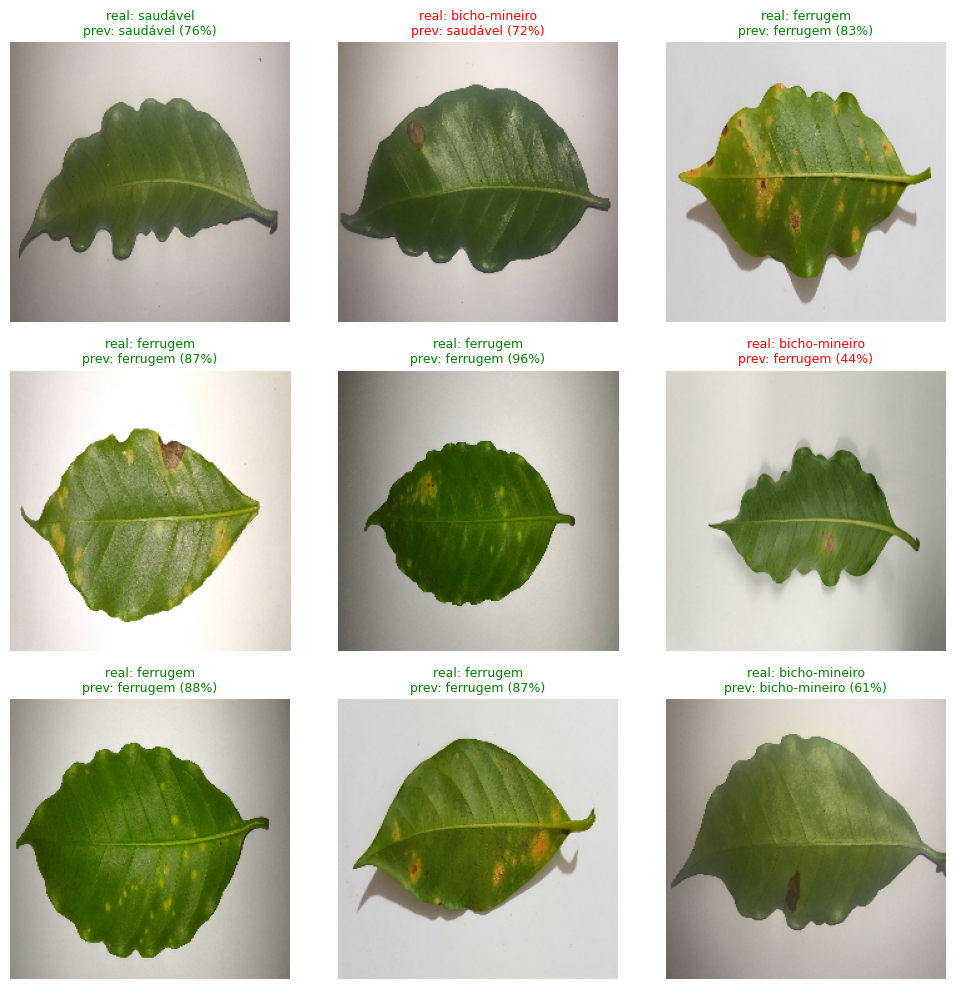

In [ ]:
imgs, lbls = next(iter(test_ds))
probs = transfer.predict(imgs, verbose=0)
pred = np.argmax(probs, axis=1); conf = probs.max(axis=1)

n = min(9, len(imgs)); fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for k, ax in enumerate(axes.flat):
    if k >= n: ax.axis("off"); continue
    ax.imshow(imgs[k].numpy().astype("uint8")); ax.axis("off")
    ok = pred[k] == int(lbls[k])
    ax.set_title(f"real: {LABELS_FIG[int(lbls[k])]}\nprev: {LABELS_FIG[pred[k]]} ({conf[k]*100:.0f}%)",
                 color="green" if ok else "red", fontsize=9)
fig.tight_layout(); fig.savefig("fig_inferencia.png", dpi=150, bbox_inches="tight"); plt.show()
